In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

renamed the 'cleaned_data3.csv' to 'cleaned_data.csv'

In [ ]:
df=pd.read_csv('cleaned_data.csv')
df.head(3)

,floor_area_sqft,remaining_lease_years,region,mrt_nearest_distance,mid,resale_price,town,Tranc_Year,flat_model_tier,bto_launched,mop_flats
0,968.760,84,C,330.083069,11,680000.0,KALLANG/WHAMPOA,2016,core,16000,12000
1,1399.320,65,C,903.659703,8,665000.0,BISHAN,2012,core,24000,8000
2,1550.016,75,W,1334.251197,14,838000.0,BUKIT BATOK,2013,premium,25000,7000


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.head())

(150634, 11)
floor_area_sqft          float64
remaining_lease_years      int64
region                    object
mrt_nearest_distance     float64
mid                        int64
resale_price             float64
town                      object
Tranc_Year                 int64
flat_model_tier           object
bto_launched               int64
mop_flats                  int64
dtype: object
   floor_area_sqft  remaining_lease_years region  mrt_nearest_distance  mid  \
0          968.760                     84      C            330.083069   11   
1         1399.320                     65      C            903.659703    8   
2         1550.016                     75      W           1334.251197   14   
3         1108.692                     70      C            907.453484    3   
4          893.412                     65      N            412.343032    2   

   resale_price             town  Tranc_Year flat_model_tier  bto_launched  \
0      680000.0  KALLANG/WHAMPOA        2016            c

In [ ]:
# Convert 'region' from categorical to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['town'], drop_first=True)
print(df.head())

   floor_area_sqft  remaining_lease_years region  mrt_nearest_distance  mid  \
0          968.760                     84      C            330.083069   11   
1         1399.320                     65      C            903.659703    8   
2         1550.016                     75      W           1334.251197   14   
3         1108.692                     70      C            907.453484    3   
4          893.412                     65      N            412.343032    2   

   resale_price  Tranc_Year flat_model_tier  bto_launched  mop_flats  ...  \
0      680000.0        2016            core         16000      12000  ...   
1      665000.0        2012            core         24000       8000  ...   
2      838000.0        2013         premium         25000       7000  ...   
3      550000.0        2012            core         24000       8000  ...   
4      298000.0        2017          legacy         15000      15000  ...   

   town_PASIR RIS  town_PUNGGOL  town_QUEENSTOWN  town_SEMBAWA

In [ ]:
# Create features X and target variable y

X = df[['floor_area_sqft', 'remaining_lease_years', 'mrt_nearest_distance', 'mid'] +
       [col for col in df.columns if col.startswith('town')]]
y = df['resale_price']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=46
)


First round

In [ ]:
# Initialise Random Forest model with 100 trees

rf_model = RandomForestRegressor(n_estimators=100, random_state=46)

# Train the model on training data
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# Make predictions on test data
y_pred = rf_model.predict(X_test)

# Evaluate model performance
print("R²  :", round(r2_score(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 2))

R²  : 0.9237
RMSE: 39600.93
MAE : 30465.28


In [ ]:
# Compare train vs test R² to check for overfitting
train_pred = rf_model.predict(X_train)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Test R² :", round(r2_score(y_test, y_pred), 4))
print("Difference:", round(r2_score(y_train, train_pred) - r2_score(y_test, y_pred), 4))

Train R²: 0.9725
Test R² : 0.9237
Difference: 0.0488


 round 2:rf_model_v2 tuning manually

In [ ]:
# Tune parameters to reduce overfitting
# max_depth limits how deep each tree can grow
# min_samples_split forces trees to only split when enough data exists
rf_model_v2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,          # limit tree depth
    min_samples_split=10,  # require at least 10 samples to split
    random_state=46)

rf_model_v2.fit(X_train, y_train)

y_pred_v2 = rf_model_v2.predict(X_test)
train_pred_v2 = rf_model_v2.predict(X_train)

print("Train R²:", round(r2_score(y_train, train_pred_v2), 4))
print("Test R² :", round(r2_score(y_test, y_pred_v2), 4))
print("Difference:", round(r2_score(y_train, train_pred_v2) - r2_score(y_test, y_pred_v2), 4))

Train R²: 0.9015
Test R² : 0.894
Difference: 0.0075


In [ ]:
# Evaluate V2 model performance
print("R²  :", round(r2_score(y_test, y_pred_v2), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_v2)), 2))
print("MAE :", round(mean_absolute_error(y_test, y_pred_v2), 2))

R²  : 0.894
RMSE: 46681.74
MAE : 35316.44


Final round: use  GridSearchCV to find the best parameter

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
param_grid = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=46),
    param_grid, cv=3, scoring='r2'
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 20, 'min_samples_split': 10}


In [ ]:
# Train final model with best parameters found by GridSearchCV
rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    random_state=46
)

rf_final.fit(X_train, y_train)

# Evaluate
y_pred_final = rf_final.predict(X_test)
train_pred_final = rf_final.predict(X_train)

print("Train R²  :", round(r2_score(y_train, train_pred_final), 4))
print("Test R²   :", round(r2_score(y_test, y_pred_final), 4))
print("Difference:", round(r2_score(y_train, train_pred_final) - r2_score(y_test, y_pred_final), 4))
print("RMSE      :", round(np.sqrt(mean_squared_error(y_test, y_pred_final)), 2))
print("MAE       :", round(mean_absolute_error(y_test, y_pred_final), 2))

Train R²  : 0.9339
Test R²   : 0.9187
Difference: 0.0152
RMSE      : 40866.35
MAE       : 31388.0


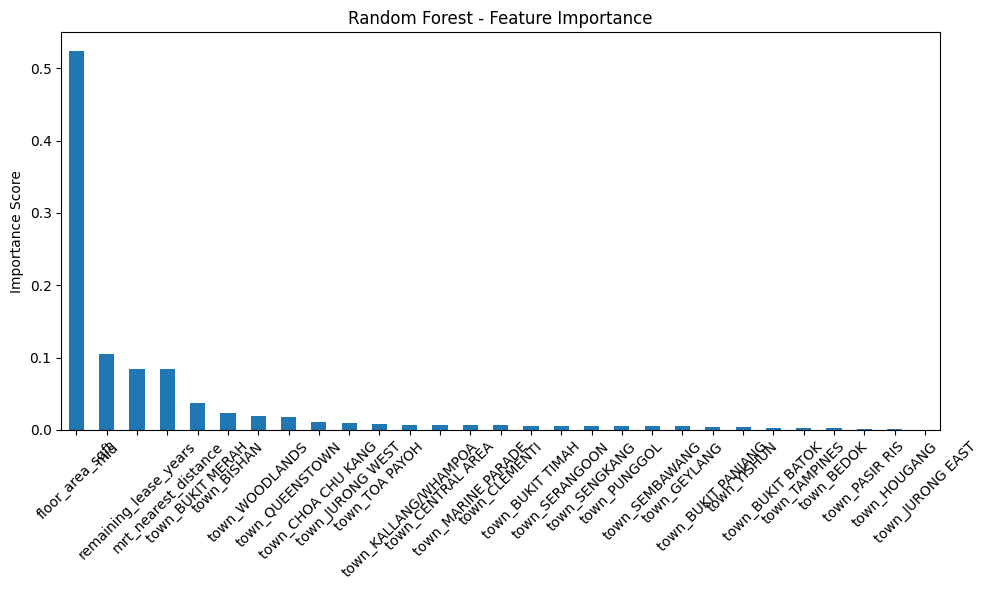

floor_area_sqft          0.523688
mid                      0.104625
remaining_lease_years    0.084025
mrt_nearest_distance     0.083873
town_BUKIT MERAH         0.037394
town_BISHAN              0.023523
town_WOODLANDS           0.019686
town_QUEENSTOWN          0.018304
town_CHOA CHU KANG       0.010790
town_JURONG WEST         0.009961
town_TOA PAYOH           0.008297
town_KALLANG/WHAMPOA     0.007162
town_CENTRAL AREA        0.006828
town_MARINE PARADE       0.006715
town_CLEMENTI            0.006188
town_BUKIT TIMAH         0.005430
town_SERANGOON           0.005227
town_SENGKANG            0.005110
town_PUNGGOL             0.004960
town_SEMBAWANG           0.004841
town_GEYLANG             0.004630
town_BUKIT PANJANG       0.004310
town_YISHUN              0.003668
town_BUKIT BATOK         0.003060
town_TAMPINES            0.003051
town_BEDOK               0.002307
town_PASIR RIS           0.000955
town_HOUGANG             0.000948
town_JURONG EAST         0.000446
dtype: float64

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance from the final model
importance = pd.Series(rf_final.feature_importances_, index=X_train.columns)

# Sort from highest to lowest
importance = importance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title('Random Forest - Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print exact values
print(importance)

In [ ]:
# Combine all town dummy columns into one total importance score

importance['town'] = importance[[col for col in importance.index if col.startswith('town')]].sum()

importance = importance.drop(index=[col for col in importance.index if col.startswith('town_')])
# Sort and print
importance = importance.sort_values(ascending=False)
importance = importance.map(lambda x: f'{x*100:.1f}%')
print(importance)

floor_area_sqft          52.4%
town                     20.4%
mid                      10.5%
remaining_lease_years     8.4%
mrt_nearest_distance      8.4%
dtype: object


In [ ]:
import joblib

# Save the model to a file
joblib.dump(rf_final, 'rf_model.pkl')

['rf_model.pkl']

In [ ]:
import joblib

rf_model = joblib.load("rf_model.pkl")

In [ ]:
print(rf_model.n_features_in_)

8


build model using region other than town

In [ ]:
region_df=pd.read_csv('cleaned_data.csv')
region_df.head(2)

,floor_area_sqft,remaining_lease_years,region,mrt_nearest_distance,mid,resale_price,town,Tranc_Year,flat_model_tier,bto_launched,mop_flats
0,968.76,84,C,330.083069,11,680000.0,KALLANG/WHAMPOA,2016,core,16000,12000
1,1399.32,65,C,903.659703,8,665000.0,BISHAN,2012,core,24000,8000


In [ ]:
region_df= pd.get_dummies(region_df, columns=['region'], drop_first=True)
print(region_df.head())


   floor_area_sqft  remaining_lease_years  mrt_nearest_distance  mid  \
0          968.760                     84            330.083069   11   
1         1399.320                     65            903.659703    8   
2         1550.016                     75           1334.251197   14   
3         1108.692                     70            907.453484    3   
4          893.412                     65            412.343032    2   

   resale_price             town  Tranc_Year flat_model_tier  bto_launched  \
0      680000.0  KALLANG/WHAMPOA        2016            core         16000   
1      665000.0           BISHAN        2012            core         24000   
2      838000.0      BUKIT BATOK        2013         premium         25000   
3      550000.0           BISHAN        2012            core         24000   
4      298000.0           YISHUN        2017          legacy         15000   

   mop_flats  region_E  region_N  region_NE  region_W  
0      12000     False     False      Fals

In [ ]:
region_df = region_df.drop(
    ['town', 'Tranc_Year', 'flat_model_tier', 'bto_launched', 'mop_flats'],
    axis=1
)

In [ ]:
# Separate features X and target variable y

X = region_df.drop(columns=['resale_price'])
y = region_df['resale_price']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=46
)

In [ ]:
# Initialise Random Forest model with 100 trees

rf_model2 = RandomForestRegressor(n_estimators=100, random_state=46)

# Train the model on training data
rf_model2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# Train final model with best parameters found by GridSearchCV
rf_model2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    random_state=46
)

rf_model2.fit(X_train, y_train)

# Evaluate
y_pred_final = rf_model2.predict(X_test)
train_pred_final = rf_model2.predict(X_train)

print("Train R²  :", round(r2_score(y_train, train_pred_final), 4))
print("Test R²   :", round(r2_score(y_test, y_pred_final), 4))
print("Difference:", round(r2_score(y_train, train_pred_final) - r2_score(y_test, y_pred_final), 4))
print("RMSE      :", round(np.sqrt(mean_squared_error(y_test, y_pred_final)), 2))
print("MAE       :", round(mean_absolute_error(y_test, y_pred_final), 2))

Train R²  : 0.9538
Test R²   : 0.9254
Difference: 0.0284
RMSE      : 39160.78
MAE       : 30155.43


In [ ]:
#the best model so far!

In [ ]:
import joblib

# Save the model to a file
joblib.dump(rf_model2, 'rf_best_model.pkl')

['rf_best_model.pkl']

This notebook builds a Random Forest regression model to predict resale prices, improving performance over linear regression by capturing non-linear relationships and feature interactions. The model achieves lower RMSE and higher explanatory power, with feature importance analysis highlighting key drivers such as floor area, lease remaining, and accessibility. It serves as a more robust predictive model while sacrificing some interpretability compared to linear regression.